
# 2 &mdash; What a covariance target can do that an $S$ target cannot

* **B.3** directional squeezed source &mdash; asymmetry *between* the port blocks
  at finite cooperativity, enforced together with a transmission pin so the
  minimal device stays connected (Sec. 11).
* **B.3(h)** thermal-resilient directional squeezer &mdash; the same device
  with a hot intrinsic-loss channel; purity under a hot bath turns out to be
  *equivalent* to noise evasion, which makes the minimal-mode question an
  obstruction question (Sec. 6 certificates).
* **B.4** broadband squeezer &mdash; point + $\Omega$-derivative pins; the decay
  ratios $\tilde\kappa_i$ are what flattens the band (App. A.4(c)).

Script version: `examples/02_directional_and_spectral.py`.

In [1]:
# In case you are using Google Colab, this cell installs AutoGaussian
import sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install "git+https://github.com/Fouriersaur/AutoGaussian.git#subdirectory=autogaussian"
    !pip install cvxpy    # optional: infeasibility certificates (Sec. 6)
else:
    # running from a clone: put the package root on sys.path
    import os
    sys.path.insert(0, os.path.abspath(os.getcwd()))

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from autogaussian import (
    CovarianceArchitectureOptimizer,
    plot_graph,
    plot_list_of_graphs,
    solution_table,
    variance_to_dB,
)
from autogaussian.gallery import broadband_squeezer, directional_squeezed_source


## B.3 &mdash; directional squeezed source

How many auxiliary modes are needed? Sec. 6(a): grow the auxiliary count until
the fully connected graph works. Two directly coupled modes cannot be made
directional by any coupling phase alone (mode-swap symmetry), so 0 auxiliaries
**must** fail here.

In [3]:
problem = directional_squeezed_source(variance=0.2, forward_transmission=1.3,
                                      isolate_backward=True)

optimizer = None
for num_auxiliary_modes in (0, 1):
    candidate = CovarianceArchitectureOptimizer(
        problem.target, num_auxiliary_modes=num_auxiliary_modes, seed=3,
        make_initial_test=False, kwargs_optimization={"num_tests": 30},
        **problem.optimizer_kwargs())
    success, infos = candidate.test_graph(candidate.space.fully_connected())
    print("  %i auxiliary modes: %-8s best loss %.2g"
          % (num_auxiliary_modes, "VALID" if success else "INVALID",
             min(info["loss_reached"] for info in infos)))
    if success:
        optimizer = candidate
        break

  0 auxiliary modes: INVALID  best loss 0.27


  1 auxiliary modes: VALID    best loss 9.5e-11


In [4]:
x = infos[-1]["x"]
V = np.real(optimizer.oracle.covariance(x, 0.0))
S, _ = optimizer.oracle.scattering(x, 0.0)

print("port covariance at Omega = 0:")
print(np.round(V, 4))
print("\nport 1 (vacuum target): diag = %.4f, %.4f" % (V[0, 0], V[1, 1]))
print("port 2 squeezing:       %.2f dB  (variance %.4f)"
      % (variance_to_dB(V[2, 2]), V[2, 2]))
print("transport: forward |S_10|^2 = %.3f, backward |S_01|^2 = %.3f"
      % (abs(S[1, 0]) ** 2, abs(S[0, 1]) ** 2))
print("stability margin: max Re eig(M~) = %.3f" % infos[-1]["max_real_eigenvalue"])

port covariance at Omega = 0:
[[ 1.0e+00  0.0e+00 -1.2e-03  2.6e-03]
 [ 0.0e+00  1.0e+00  5.0e-04  5.9e-03]
 [-1.2e-03  5.0e-04  2.0e-01  0.0e+00]
 [ 2.6e-03  5.9e-03  0.0e+00  5.0e+00]]

port 1 (vacuum target): diag = 1.0000, 1.0000
port 2 squeezing:       6.99 dB  (variance 0.2000)
transport: forward |S_10|^2 = 1.300, backward |S_01|^2 = 0.000
stability margin: max Re eig(M~) = -0.011



### Which elements does the solution actually need?

A full breadth-first search over this lattice is expensive &mdash; 3 modes give 12
slots, i.e. $3^{12} \approx 5\cdot10^5$ graphs, and every verdict costs up to 30
restarts. `greedy_minimal_subgraph` is the cheap descent instead: weaken one slot
at a time for as long as the graph stays valid. It returns *a* minimal device (not
the complete irreducible set &mdash; that is `minimal_valid_subgraphs`), which is
enough to see what directionality really requires.

In [5]:
minimal = optimizer.greedy_minimal_subgraph(optimizer.space.fully_connected(),
                                            num_tests=10, verbose=True)
print("\na minimal setup: %s" % ", ".join(optimizer.space.describe(minimal)))

solution = optimizer.solution_of(minimal)
if solution is None:
    success_min, infos_min = optimizer.test_graph(minimal, num_tests=30)
    solution = infos_min[-1]

V = np.real(optimizer.oracle.covariance(solution["x"], 0.0))
S, _ = optimizer.oracle.scattering(solution["x"], 0.0)
print("port 1 = [%.4f, %.4f] (vacuum)   port 2 = %.4f (%.2f dB)"
      % (V[0, 0], V[1, 1], V[2, 2], variance_to_dB(V[2, 2])))
print("transport: forward %.3f   backward %.3f"
      % (abs(S[1, 0]) ** 2, abs(S[0, 1]) ** 2))
print("stability margin: %.4f" % solution["max_real_eigenvalue"])

report = optimizer.param.physical_report(solution["x"])
for section in ("cooperativities", "phases", "detunings", "decay_ratios"):
    if report[section]:
        print("\n%s:" % section)
        for key, value in report[section].items():
            print("   %-16s %.4f" % (key, value))

   -> beam-splitter 0-1 (complex), beam-splitter 0-2 (complex), detuning Delta_1, beam-splitter 1-2 (complex), detuning Delta_2, on-site squeezing 0 (complex), two-mode squeezing 0-1 (complex), two-mode squeezing 0-2 (complex), on-site squeezing 1 (complex), two-mode squeezing 1-2 (complex), on-site squeezing 2 (complex)


   -> beam-splitter 0-1 (complex), beam-splitter 0-2 (real), detuning Delta_1, beam-splitter 1-2 (complex), detuning Delta_2, on-site squeezing 0 (complex), two-mode squeezing 0-1 (complex), two-mode squeezing 0-2 (complex), on-site squeezing 1 (complex), two-mode squeezing 1-2 (complex), on-site squeezing 2 (complex)


   -> beam-splitter 0-1 (real), beam-splitter 0-2 (real), detuning Delta_1, beam-splitter 1-2 (complex), detuning Delta_2, on-site squeezing 0 (complex), two-mode squeezing 0-1 (complex), two-mode squeezing 0-2 (complex), on-site squeezing 1 (complex), two-mode squeezing 1-2 (complex), on-site squeezing 2 (complex)


   -> beam-splitter 0-1 (real), beam-splitter 0-2 (real), detuning Delta_1, beam-splitter 1-2 (complex), on-site squeezing 0 (complex), two-mode squeezing 0-1 (complex), two-mode squeezing 0-2 (complex), on-site squeezing 1 (complex), two-mode squeezing 1-2 (complex), on-site squeezing 2 (complex)


   -> beam-splitter 0-1 (real), beam-splitter 0-2 (real), beam-splitter 1-2 (complex), on-site squeezing 0 (complex), two-mode squeezing 0-1 (complex), two-mode squeezing 0-2 (complex), on-site squeezing 1 (complex), two-mode squeezing 1-2 (complex), on-site squeezing 2 (complex)


...

   -> beam-splitter 0-1 (real), beam-splitter 0-2 (real), beam-splitter 1-2 (complex), two-mode squeezing 0-1 (real), two-mode squeezing 0-2 (real), two-mode squeezing 1-2 (complex), on-site squeezing 2 (complex)


   -> beam-splitter 0-1 (real), beam-splitter 0-2 (real), beam-splitter 1-2 (complex), two-mode squeezing 0-1 (real), two-mode squeezing 1-2 (complex), on-site squeezing 2 (complex)


   -> beam-splitter 0-1 (real), beam-splitter 0-2 (real), beam-splitter 1-2 (complex), two-mode squeezing 0-1 (real), two-mode squeezing 1-2 (complex), on-site squeezing 2 (real)


   -> beam-splitter 0-1 (real), beam-splitter 0-2 (real), beam-splitter 1-2 (complex), two-mode squeezing 0-1 (real), two-mode squeezing 1-2 (complex)



a minimal setup: beam-splitter 0-1 (real), beam-splitter 0-2 (real), beam-splitter 1-2 (complex), two-mode squeezing 0-1 (real), two-mode squeezing 1-2 (complex)
port 1 = [1.0000, 1.0000] (vacuum)   port 2 = 0.2000 (6.99 dB)
transport: forward 1.300   backward 0.000
stability margin: -0.4993

cooperativities:
   C^{BS}_{0,1}     0.5614
   C^{SQZ}_{0,1}    0.2487
   C^{BS}_{0,2}     0.3097
   C^{BS}_{1,2}     1.8125
   C^{SQZ}_{1,2}    0.8079

phases:
   arg(g_{0,1})     0.0000
   arg(nu_{0,1})    0.0000
   arg(g_{0,2})     3.1416
   arg(g_{1,2})     -1.5708
   arg(nu_{1,2})    1.5708

decay_ratios:
   kappa~_0         1.0000
   kappa~_1         1.0000
   kappa~_2         1.0000


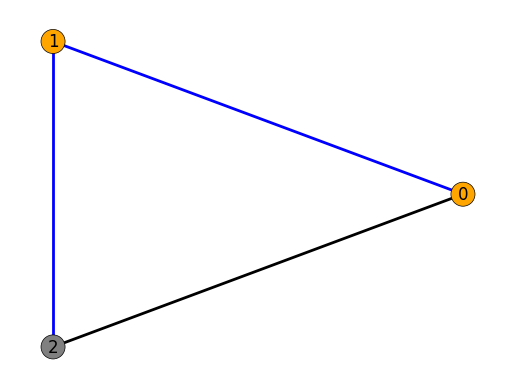

In [6]:
# modes 0, 1 are the ports (orange), mode 2 is the damped auxiliary (gray)
plot_graph(minimal, optimizer.space, ax=plt.gca(),
           node_colors=["orange", "orange", "gray"])
plt.show()

## B.3(h) &mdash; thermal-resilient directional squeezer (hot channel)

The $\sigma_{\rm out}(\Omega)$-native twin of AUTOSCATTER's "quantum-limited
amplifier with a **hot output port**" (Sec. VI). Same device as B.3 &mdash; one port
squeezed, one at vacuum, transport nonreciprocal &mdash; plus one adversary: a
designated **intrinsic-loss channel held at occupation $\bar n > 0$**, with the
monitored port still required to sit on the purity floor $\det\sigma_{\rm out}=1$.

Split the output covariance by input block,

$$\sigma_{\rm out}(\Omega) = \underbrace{S\,\sigma_{\rm signal}S^\dagger}_{\text{the squeezing}}
   + \underbrace{N\,\sigma_{\rm noise}N^\dagger}_{\text{the loss channels}},
   \qquad N(\Omega)=\chi(\Omega)\sqrt{\gamma}.$$

A cold channel contributes the identity; occupation $\bar n$ on channel $k^\*$
inflates the monitored port-$j$ block by

$$\Delta\sigma_{{\rm out},jj}(\Omega) = 2\bar n\,[\,N(\Omega)\,e_{k^\*}\,N(\Omega)^\dagger\,]_{jj},$$

so the contamination is governed entirely by $N_{j,k^\*}(\Omega)$ &mdash; the
covariance-resolved form of the added-noise sum
$N^{\rm add}=\tfrac12\sum_k[(n^{\rm in}_k+1)|S_{jk}|^2+(n^{\rm noise}_k+1)|N_{jk}|^2]$.

Two things make this a target rather than a relabelling of B.3:

* the squeezing is pinned **gauge-free**, as the eigenvalue pair
  $(e^{-2r},e^{+2r})$ of the port block, and the purity floor $\det=1$ is a
  separate equality constraint evaluated *with the bath already hot*;
* the hot channel's intrinsic loss is a live variable **with a floor**. Without
  the floor the optimiser defeats the bath by sending $\gamma_{k^\*}\to 0$ &mdash; it
  disconnects the channel instead of surviving it, and the target quietly
  becomes the cold one.

In [ ]:
from autogaussian import (
    certify_fit_infeasible,
    certify_hot_purity_obstruction,
    noise_response_block,
)
from autogaussian.gallery import hot_channel_inflation, thermal_directional_squeezer

VARIANCE  = 0.2                      # the same squeezing depth B.3 uses above
R         = -0.5 * np.log(VARIANCE)  # e^{-2r} = 0.2  ->  7.0 dB
HOT       = 2                        # the hot channel: mode 2, the first auxiliary
N_THERMAL = 0.5
GAMMA_MIN = 0.1                      # the bath is real hardware, not a free knob
TRANSMISSION = 1.3


def pose(n_thermal, num_auxiliary_modes, hot_channel=HOT, num_tests=60, seed=1, **kwargs):
    problem = thermal_directional_squeezer(
        r=R, n_thermal=n_thermal, hot_channel=hot_channel, min_loss=GAMMA_MIN,
        forward_transmission=TRANSMISSION, **kwargs)
    return CovarianceArchitectureOptimizer(
        problem.target, num_auxiliary_modes=num_auxiliary_modes, seed=seed,
        make_initial_test=False, kwargs_optimization={"num_tests": num_tests},
        **problem.optimizer_kwargs())


def readout(optimizer, x, label):
    V = np.real(optimizer.oracle.covariance(x, 0.0))
    S, _ = optimizer.oracle.scattering(x, 0.0)
    block = V[2:4, 2:4]
    lo, hi = np.linalg.eigvalsh(block)
    print("%-14s eig (%.4f, %.4f) = %.2f dB | det %.7f | forward %.3f  backward %.1e"
          % (label, lo, hi, variance_to_dB(lo), np.linalg.det(block),
             abs(S[1, 0]) ** 2, abs(S[0, 1]) ** 2))
    print("%-14s gamma = %s" % ("", np.round(np.asarray(optimizer.param.gamma(x)), 4)))
    return block


# 1. cold baseline: the same open loss channel, but at vacuum
cold = pose(0.0, num_auxiliary_modes=1)
ok_cold, infos_cold = cold.test_graph(cold.space.fully_connected())
print("cold bath, 1 auxiliary mode:", "VALID" if ok_cold else "INVALID")
x_cold = infos_cold[-1]["x"]
block_cold = readout(cold, x_cold, "cold witness")

### The break: heat the channel, do not re-fit

Same graph, same converged parameters, one number changed. The textbook device
must fail purity *on purpose*, and it must fail by exactly the amount the
inflation formula predicts &mdash; that is the check that the bath enters where the
algebra says it does.

In [ ]:
hot_same = pose(N_THERMAL, num_auxiliary_modes=1, num_tests=1)
block_hot = np.real(hot_same.oracle.covariance(x_cold, 0.0))[2:4, 2:4]

H, gamma, kappa_tilde, _ = cold.param.unpack(x_cold)
predicted = hot_channel_inflation(
    N_THERMAL,
    noise_response_block(H, gamma, kappa_tilde, 0.0, port=1, channel=HOT,
                         thetas=np.zeros(cold.num_modes)))

print("measured  d sigma_out,11 =\n", np.round(block_hot - block_cold, 6))
print("predicted 2n [N e_k N^dag] =\n", np.round(predicted, 6))
print("\nmax deviation: %.2e" % np.max(np.abs(block_hot - block_cold - predicted)))
print("det sigma_out,11:  %.6f (cold)  ->  %.6f (hot)"
      % (np.linalg.det(block_cold), np.linalg.det(block_hot)))

### Where the bath sits is not a free choice

Write the monitored block as $A+B$, with $A$ the block the *same* device would
emit with a cold bath and $B = 2\bar n[N e_{k^\*}N^\dagger]_{jj}$. Then $A$ is a
physical single-mode covariance, so $\det A \ge 1$, and $B\succeq 0$. For $2\times2$
blocks $\det(A+B)=\det A+\det B+\operatorname{tr}(A\,\mathrm{adj}\,B)$, so

$$\det\sigma_{{\rm out},jj} \;\ge\; \det A \;\ge\; 1,
\qquad\text{with equality iff } B=0 .$$

**Purity under a hot bath is exactly noise evasion**, $N_{j,k^\*}=0$. That is a
theorem about this forward map, not a conjecture about the mechanism &mdash; and it
turns the placement of the hot channel into a decidable question. Put the bath on
the *other port's* mode and $N_{jk}=S_{jk}\sqrt{\gamma_k}$: the pinned forward
transmission itself forces $B\neq0$. No graph, at any mode count, can hold
$\det=1$, and the fit-range certificate says so before a single restart is spent.

In [ ]:
for num_auxiliary_modes in (1, 2, 3):
    on_port = pose(N_THERMAL, num_auxiliary_modes, hot_channel=0, num_tests=1,
                   intrinsic_losses=[True])
    fired, detail = certify_hot_purity_obstruction(on_port, on_port.space.fully_connected())
    print("hot channel on the port-2 mode, %i auxiliaries -> certified infeasible: %s"
          % (num_auxiliary_modes, fired))
    if fired:
        print("      %s   (forced by %s)" % (detail["bound"], detail["forcing_constraint"]))

# on an auxiliary mode nothing is proved, so nothing is claimed
on_aux = pose(N_THERMAL, 2, num_tests=1)
print("\nhot channel on the auxiliary  -> certified infeasible:",
      certify_hot_purity_obstruction(on_aux, on_aux.space.fully_connected())[0])

### The cost of resilience

With the bath on an auxiliary, evasion is possible and the question becomes a
real minimisation. One auxiliary mode &mdash; enough for the cold device &mdash; is not
enough once the bath is hot: the fit misses on *every* restart, and nothing
certifies it, so the verdict is a **provisional, non-condemning** invalid. Adding
one mode flips it VALID. The assertion is the transition, not the count.

Note what the restart tally shows about stability: it binds hard here, but not in
the way the constrained stability search fixes. Most parameter points that reach
the fit tolerance are unstable, and the hinge search does not walk them back to
the stable region &mdash; the stable witness comes from restarting into a *different
feasible component*, which is the second role Sec. 5 gives the restarts.

In [ ]:
hot_1 = pose(N_THERMAL, num_auxiliary_modes=1)
ok_1, infos_1 = hot_1.test_graph(hot_1.space.fully_connected())
print("hot bath, 1 auxiliary mode: %s   best loss %.2g   restarts reaching the fit: %i/%i"
      % ("VALID" if ok_1 else "INVALID", min(i["loss_reached"] for i in infos_1),
         sum(i["loss_below_tolerance"] for i in infos_1), len(infos_1)))
print("   certificate fired:",
      certify_fit_infeasible(hot_1, hot_1.space.fully_connected(), cache={})[0],
      "-> provisional invalid; this graph may NOT condemn its subgraphs")

hot_2 = pose(N_THERMAL, num_auxiliary_modes=2)
ok_2, infos_2 = hot_2.test_graph(hot_2.space.fully_connected(),
                                 interrupt_if_successful=False)
fit_points = [i for i in infos_2 if i["loss_below_tolerance"]]
rescued = [i for i in fit_points if i["stability_search"] and i["stability_search"]["success"]]
print("\nhot bath, 2 auxiliary modes: %s" % ("VALID" if ok_2 else "INVALID"))
print("   %i/%i restarts reached the fit; %i of those were stable; "
      "%i were rescued by the constrained stability search"
      % (len(fit_points), len(infos_2),
         sum(i["stable"] for i in fit_points), len(rescued)))
print("   abscissae at the fit points:",
      np.round([i["max_real_eigenvalue"] for i in fit_points], 3))

x_hot = next(i["x"] for i in infos_2 if i["success"])
block_resilient = readout(hot_2, x_hot, "resilient")

In [ ]:
# what the converged witness actually uses (Sec. 6 reduction, read off the solution)
reduced = hot_2.reduce_graph(x_hot)
print("elements in use: %i of %i slots" % (int(np.sum(reduced != 0)), hot_2.space.num_slots))
if int(np.sum(reduced != 0)) == hot_2.space.num_slots:
    print("   nothing came out zero: this reads off one solution, it does not minimise.")
    print("   the irreducible devices need the Sec. 6 descent "
          "(greedy_minimal_subgraph / minimal_valid_subgraphs), which is expensive here")
    print("   because only ~1 restart in 10 lands a stable witness.")

# modes 0, 1 are the ports (orange), mode 2 carries the hot bath (red), mode 3 is cold (gray)
plot_graph(reduced, hot_2.space, ax=plt.gca(),
           node_colors=["orange", "orange", "red", "gray"])
plt.show()

### Evasion, measured &mdash; and what it does *not* buy

The theorem says a witness on the purity floor must have $N_{1,k^\*}\to0$; the
diagnostic checks it rather than assuming it, and then asks the broadband
question separately. Decomposing $\det\sigma_{{\rm out},11}(\Omega)$ into the
cold block $\det A$ and the bath's contribution $\|B\|$ separates the two reasons
purity can fail away from $\Omega=0$.

In [ ]:
H_h, gamma_h, kappa_h, _ = hot_2.param.unpack(x_hot)
cold_2 = pose(0.0, num_auxiliary_modes=2, num_tests=1)   # same device, cold bath -> A
band = np.linspace(0.0, 0.5, 11)

norm_B, det_total, det_A = [], [], []
for omega in band:
    B = hot_channel_inflation(
        N_THERMAL,
        noise_response_block(H_h, gamma_h, kappa_h, omega, port=1, channel=HOT,
                             thetas=np.zeros(hot_2.num_modes)))
    norm_B.append(np.linalg.norm(B))
    det_total.append(np.linalg.det(np.real(hot_2.oracle.covariance(x_hot, omega))[2:4, 2:4]))
    det_A.append(np.linalg.det(np.real(cold_2.oracle.covariance(x_hot, omega))[2:4, 2:4]))

print("Omega=0:  ||B|| = %.2e,  det = %.8f  ->  the witness evades the hot channel"
      % (norm_B[0], det_total[0]))

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2))
axes[0].semilogy(band, norm_B, "o-", ms=3)
axes[0].set_xlabel(r"$\Omega$"); axes[0].set_ylabel(r"$\|2\bar n\,N e_{k^*} N^\dagger\|$")
axes[0].set_title("bath reaching the monitored port")
axes[1].plot(band, det_total, "o-", ms=3, label=r"$\det\sigma_{\rm out,11}$ (hot)")
axes[1].plot(band, det_A, "--", lw=1.2, label=r"$\det A$ (same device, cold)")
axes[1].axhline(1.0, color="k", ls=":", lw=0.8, label="purity floor")
axes[1].set_xlabel(r"$\Omega$"); axes[1].set_ylabel("determinant")
axes[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

**VERIFY-FIRST, item 1 (broadband).** The sweep decides it: purity holds at
$\Omega=0$ and collapses immediately away from it, and the two curves above show
*why* &mdash; the bath's contribution $\|B\|$ stays flat and tiny across the band,
while $\det A$, the same device's own cold dispersion, is what lifts the
determinant. Holding $\det=1$ over a finite band is therefore not a hot-channel
question at all on this witness, and the target stays at $\Omega=0$. The
`bandwidth` argument of `thermal_directional_squeezer` exists but is off by
default for exactly this reason.

### The continuous class (Sec. VI payoff)

Fix the resilient topology and sweep the adversary. The construction rules come
out **constant in $\bar n$** &mdash; which is not a failure of the regression but the
signature of the mechanism: once evasion is exact, the device no longer knows how
hot the bath is. The last check makes that explicit by evaluating the
$\bar n = 0.5$ witness against baths it was never fitted to.

In [ ]:
graph = hot_2.space.fully_connected()
free_idxs = hot_2.param.free_indices(graph)
warm, rows = np.asarray(x_hot), []

for n_thermal in (0.2, 0.4, 0.6, 0.8):
    swept = pose(n_thermal, num_auxiliary_modes=2, num_tests=1)
    success, info = swept.oracle.optimize(free_idxs, x0=warm[free_idxs])
    if not success:                      # guard: a point the fixed topology cannot host
        success, infos = swept.test_graph(graph, num_tests=40)
        info = infos[-1]
    if not success:
        print("n = %.2f: fixed topology fails here -- the Sec. VI premise breaks, "
              "split the sweep" % n_thermal)
        continue
    warm = np.asarray(info["x"])
    report = swept.param.physical_report(info["x"])
    rows.append((n_thermal, report))
    print("n = %.2f  alpha %+0.3f   C_02^BS %.4f   C_03^BS %.4f   gamma_2 %.4f"
          % (n_thermal, info["max_real_eigenvalue"],
             report["cooperativities"]["C^{BS}_{0,2}"],
             report["cooperativities"]["C^{BS}_{0,3}"],
             report["intrinsic_losses"]["gamma_2"]))

print("\nthe n = %.1f witness, evaluated against baths it was never fitted to:" % N_THERMAL)
for n_thermal in (0.0, 2.0, 10.0, 100.0):
    check = pose(n_thermal, num_auxiliary_modes=2, num_tests=1)
    block = np.real(check.oracle.covariance(x_hot, 0.0))[2:4, 2:4]
    print("   n = %6.1f :  eig (%.5f, %.5f)   det %.8f"
          % (n_thermal, *np.linalg.eigvalsh(block), np.linalg.det(block)))

### What this run establishes, and what it does not

**Established here.** The bath enters only through $N$, by the inflation formula
(checked to machine precision against the forward map). Purity under a hot bath
is *equivalent* to exact evasion $N_{j,k^\*}=0$ &mdash; proved, not conjectured, and
wired into a fit-range certificate that condemns the whole family when the target
forces the bath onto the monitored port. Where evasion is possible, resilience
costs one auxiliary mode above the cold baseline, as a transition, and the
resilient witness is $\bar n$-independent.

**Measured, not assumed.** The mechanism *is* noise evasion here &mdash; but that was
read off $N_{1,k^\*}$ and forced by the theorem, not asserted in advance.

**Not established.** No exact minimal mode count is claimed: 1 auxiliary is a
provisional invalid, not a certified one. Purity across a finite band was tested
and collapsed to a point on this witness, so no broadband variant is promoted.
The mode-count transition was measured at one $(r,\bar n,$ transmission$)$ point;
nothing here says it is sharp elsewhere.

**Gallery.** This sharpens the prescribed-impurity target &mdash; $\bar n$ is fixed as
an adversary and maximal purity is demanded, rather than an impurity curve being
prescribed. It has no gallery slot yet, and earning one is a separate step: the
entry goes into the target gallery *before* any number here joins the certified
set.


## B.4 &mdash; broadband squeezer

$\sigma_{xx} = 0.5$, flat across $|\Omega| \le 0.5$.

Derivative pins alone only constrain the spectrum *at* $\Omega = 0$ &mdash; the
optimiser can satisfy them by shrinking $\tilde\kappa$ instead of widening the
band, so the band itself is pinned as well.

In [7]:
bandwidth = 0.5
problem = broadband_squeezer(variance=0.5, num_derivatives=2, bandwidth=bandwidth)
print(problem.target)

optimizer_bb = CovarianceArchitectureOptimizer(
    problem.target, num_auxiliary_modes=1, seed=1, make_initial_test=False,
    kwargs_optimization={"num_tests": 25}, **problem.optimizer_kwargs())
success, infos_bb = optimizer_bb.test_graph(optimizer_bb.space.fully_connected())
print("fully connected graph:", "VALID" if success else "INVALID",
      " loss %.2g" % infos_bb[-1]["loss_reached"])

CovarianceTarget(broadband squeezer, 1 ports, 7 pins)
  sigma_out[0,0](Omega=0) = 0.5   (w=1, full)
  d^1/dOmega^1 sigma_out[0,0](Omega=0) = 0.0   (w=1, full)
  d^2/dOmega^2 sigma_out[0,0](Omega=0) = 0.0   (w=1, full)
  sigma_out[0,0](Omega=-0.5) = (0.5+0j)   (w=1, full)
  sigma_out[0,0](Omega=-0.25) = (0.5+0j)   (w=1, full)
  sigma_out[0,0](Omega=0.25) = (0.5+0j)   (w=1, full)
  sigma_out[0,0](Omega=0.5) = (0.5+0j)   (w=1, full)


fully connected graph: VALID  loss 8.5e-11


decay ratios found: {'kappa~_0': 23.692541137430503, 'kappa~_1': 1.3697048273527166}


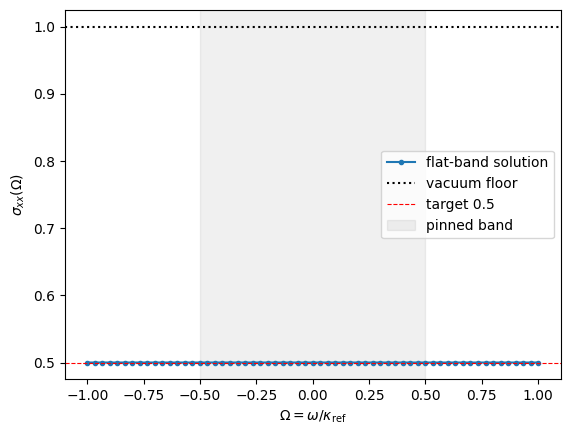

In [8]:
x_bb = infos_bb[-1]["x"]
omegas = np.linspace(-1.0, 1.0, 61)
spectrum = np.array([np.real(optimizer_bb.oracle.covariance(x_bb, w)[0, 0])
                     for w in omegas])

print("decay ratios found:", optimizer_bb.param.physical_report(x_bb)["decay_ratios"])

plt.plot(omegas, spectrum, "o-", ms=3, label="flat-band solution")
plt.axhline(1.0, color="k", ls=":", label="vacuum floor")
plt.axhline(0.5, color="r", ls="--", lw=0.8, label="target 0.5")
plt.axvspan(-bandwidth, bandwidth, color="k", alpha=0.06, label="pinned band")
plt.xlabel(r"$\Omega = \omega/\kappa_{\rm ref}$")
plt.ylabel(r"$\sigma_{xx}(\Omega)$")
plt.legend()
plt.show()


### The full search for B.4

This lattice is small enough to search exhaustively: 2 modes give 6 slots, i.e.
$3^6 = 729$ graphs. `perform_breadth_first_search` runs the complete Sec. 6 loop
(two-library engine) and returns the irreducible devices that produce the flat
band.

`num_tests` is lowered to 8 here to keep the notebook interactive. Fewer restarts
means the oracle is more likely to miss a valid parameter point, so a graph can be
called invalid when it is not; the two-library engine records that as a
*provisional* rather than certified verdict &mdash; see `optimizer.libraries`.

In [9]:
optimizer_search = CovarianceArchitectureOptimizer(
    problem.target, num_auxiliary_modes=1, seed=1, make_initial_test=False,
    kwargs_optimization={"num_tests": 8}, **problem.optimizer_kwargs())

irreducibles_bb = optimizer_search.perform_breadth_first_search(progress=False)

print("%i irreducible graphs (%i oracle calls)"
      % (len(irreducibles_bb), sum(optimizer_search.num_tested_graphs)))
for graph in sorted(irreducibles_bb, key=lambda g: int(np.sum(g))):
    print("   complexity %i:  %s"
          % (int(np.sum(graph)), ", ".join(optimizer_search.space.describe(graph))))
print()
print(optimizer_search.report())

start breadth-first search over 6 slots (max complexity 10)
test 1 graphs with 10 degrees of freedom:


test 6 graphs with 9 degrees of freedom:


test 19 graphs with 8 degrees of freedom:


test 40 graphs with 7 degrees of freedom:


test 61 graphs with 6 degrees of freedom:


...

test 61 graphs with 4 degrees of freedom:


      certificate fired: passive_range
test 37 graphs with 3 degrees of freedom:


test 15 graphs with 2 degrees of freedom:


test 3 graphs with 1 degrees of freedom:


valid: 265    invalid: 47 (certified 1, uncertified 46)    oracle calls: 1175    escalations: 46
optimisation finished, list of irreducible graphs has 10 elements (46 uncertified rejections)
10 irreducible graphs (311 oracle calls)
   complexity 2:  on-site squeezing 0 (complex)
   complexity 2:  beam-splitter 0-1 (real), two-mode squeezing 0-1 (real)
   complexity 2:  detuning Delta_0, on-site squeezing 0 (real)
   complexity 3:  beam-splitter 0-1 (real), on-site squeezing 1 (complex)
   complexity 3:  beam-splitter 0-1 (real), detuning Delta_1, on-site squeezing 1 (real)
   complexity 3:  beam-splitter 0-1 (real), detuning Delta_1, on-site squeezing 0 (real)
   complexity 3:  beam-splitter 0-1 (complex), on-site squeezing 1 (real)
   complexity 4:  detuning Delta_1, two-mode squeezing 0-1 (real), on-site squeezing 1 (complex)
   complexity 4:  detuning Delta_1, two-mode squeezing 0-1 (complex), on-site squeezing 1 (real)
   complexity 4:  detuning Delta_1, on-site squeezing 0 (real),

Every irreducible broadband device with its converged parameters.


In [10]:
print(solution_table(optimizer_search, irreducibles_bb, limit=6))


10 valid graph(s), with the converged parameters:

#0  complexity=2  couplings=1  pumps=1
      on-site squeezing 0 (complex)
      loss=7.37e-11   max Re eig(M~)=-0.9854
      cooperativities:
         C_{0,0}              +0.1009
      phases:
         arg(nu_{0,0})        -1.0472
      decay_ratios:
         kappa~_0             +24.9948
         kappa~_1             +1.9708

#1  complexity=2  couplings=2  pumps=1
      beam-splitter 0-1 (real)
      two-mode squeezing 0-1 (real)
      loss=9.41e-11   max Re eig(M~)=-4.9526
      cooperativities:
         C^{BS}_{0,1}         +2.4181
         C^{SQZ}_{0,1}        +0.3774
      phases:
         arg(g_{0,1})         +3.1416
         arg(nu_{0,1})        +3.1416
      decay_ratios:
         kappa~_0             +4.1108
         kappa~_1             +15.6995

#2  complexity=2  couplings=1  pumps=1
      detuning Delta_0
      on-site squeezing 0 (real)
      loss=9.93e-11   max Re eig(M~)=-0.3863
      cooperativities:
         C_{0,0} 

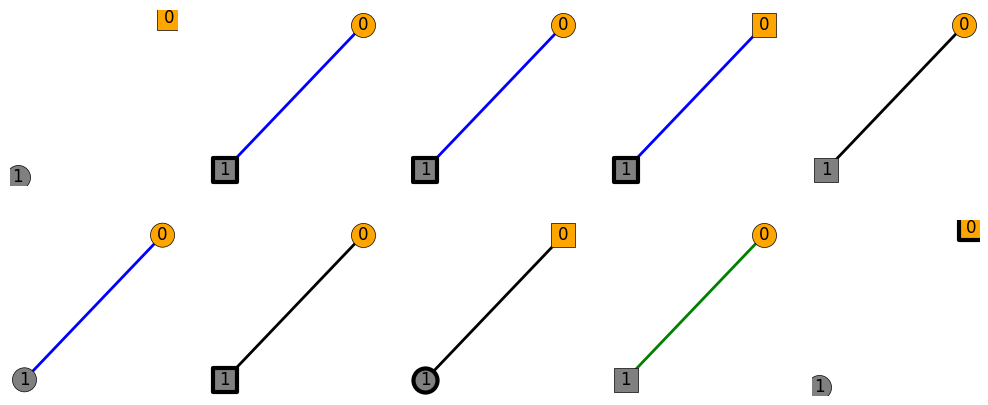

In [11]:
fig, axes = plot_list_of_graphs(irreducibles_bb, optimizer_search.space,
                                node_colors=["orange", "gray"])
plt.show()


The spectrum of every irreducible device, so the flat band can be compared across
architectures rather than read off a single solution:

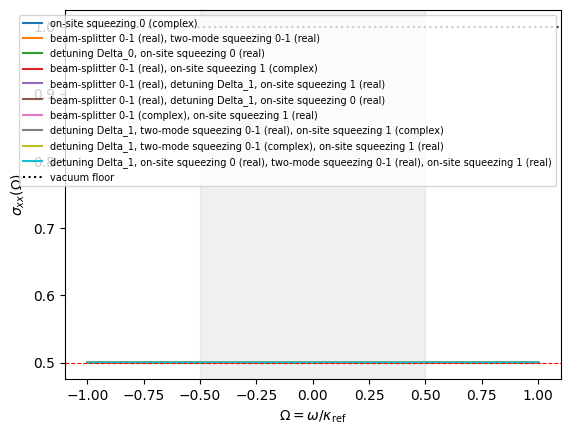

In [12]:
for graph in sorted(irreducibles_bb, key=lambda g: int(np.sum(g))):
    solution = optimizer_search.solution_of(graph)
    if solution is None:
        ok, infos = optimizer_search.test_graph(graph, num_tests=20)
        if not ok:
            continue
        solution = infos[-1]
    spectrum = np.array([np.real(optimizer_search.oracle.covariance(solution["x"], w)[0, 0])
                         for w in omegas])
    plt.plot(omegas, spectrum, "-",
             label=", ".join(optimizer_search.space.describe(graph)))

plt.axhline(1.0, color="k", ls=":", label="vacuum floor")
plt.axhline(0.5, color="r", ls="--", lw=0.8)
plt.axvspan(-bandwidth, bandwidth, color="k", alpha=0.06)
plt.xlabel(r"$\Omega = \omega/\kappa_{\rm ref}$")
plt.ylabel(r"$\sigma_{xx}(\Omega)$")
plt.legend(fontsize=7, loc="upper right")
plt.show()